**Importing Necessory Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
import sklearn.metrics as metrics

**Mounting with Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/DS_H_Features Face_Parts/DS_H_Features Eyes.csv'
df = pd.read_csv(file_path)

In [ ]:
df.head()

,image_name,0,1,2,3,4,5,6,7,8,...,2039,2040,2041,2042,2043,2044,2045,2046,2047,DownSyndromeStatus
0,eyes_down_592.jpg,0.009893,0.078810,0.108159,2.327182,1.455677,2.199442,0.220006,0.099529,0.099102,...,1.537487,2.800470,0.071357,0.460511,0.000000,0.072167,0.220605,0.106246,0.000108,1
1,eyes_down_543.jpg,0.029197,0.326666,0.133564,2.527840,1.460733,1.384271,0.207266,0.299012,0.172454,...,0.063969,0.291389,0.028089,0.015796,0.000000,0.000937,0.087100,0.548306,0.002625,1
2,eyes_down_588.jpg,0.000000,0.165873,0.102519,3.477882,1.216024,2.611108,0.150637,0.079547,0.085626,...,1.410408,1.859102,0.000000,0.467494,0.000000,0.015818,0.000000,0.192891,0.000000,1
3,eyes_down_545.jpg,0.001244,0.294278,0.134935,4.188012,0.533528,2.844821,0.123944,0.046746,0.169163,...,2.169891,1.535049,0.028806,0.527630,0.018825,0.110196,0.066302,0.026837,0.000000,1
4,eyes_down_601.jpg,0.000000,0.110918,0.139218,3.371179,1.158892,2.737678,0.289980,0.054734,0.033683,...,0.038066,0.124092,0.216795,0.014176,0.000000,0.087166,0.082841,0.382244,0.000000,1


In [ ]:
#checking for null values
df.isnull().sum()

,0
image_name,0
0,0
1,0
2,0
3,0
...,...
2044,0
2045,0
2046,0
2047,0


In [ ]:
#null value count
df.isnull().sum().sum()

0

In [ ]:
#Dropping the target coloumn (DownSyndromeStatus) and 'image_name' column as it's not relevant for prediction
X=df.drop(['DownSyndromeStatus','image_name'],axis=1)
y=df['DownSyndromeStatus']

In [ ]:
#Spliting the data with 80:20 ratio
#Spliting the data with 70:30 ratio
#Spliting the data with 60:40 ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Creating an SVM classifier
svm = SVC(kernel='linear', probability=True)  # 'probability=True' is required for ROC

#Fitting model
svm.fit(X_train, y_train)

#Evaluating the Model
#Prediction on the test set
y_pred = svm.predict(X_test)

In [ ]:
#Calculating accuracy
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print('Confusion Matrix:')
print(conf_matrix)


#Classification report
class_report = classification_report(y_test, y_pred)
print('Classification Report:')
print(class_report)

Accuracy: 0.81
Confusion Matrix:
[[227  48]
 [ 62 257]]
Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.80       275
           1       0.84      0.81      0.82       319

    accuracy                           0.81       594
   macro avg       0.81      0.82      0.81       594
weighted avg       0.82      0.81      0.82       594



**Confusion Matrix**

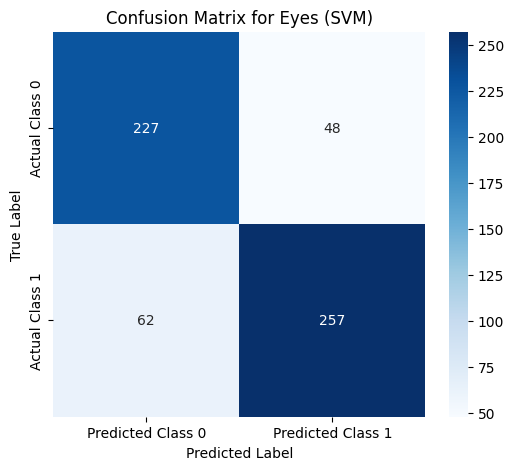

In [ ]:
#Creating heatmap for confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted Class 0', 'Predicted Class 1'],
            yticklabels=['Actual Class 0', 'Actual Class 1'])

#giving labels, title, and displaying the plot
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Eyes (SVM)')
plt.show()

**Area Under the Curve Score**

In [ ]:
#Getting the decision function scores for the test set
y_scores = svm.decision_function(X_test)

#Computing False Positive Rate (FPR), True Positive Rate (TPR), and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

#Calculating AUC
roc_auc = auc(fpr, tpr)
print(f'AUC: {roc_auc:.2f}')

AUC: 0.90


**ROC (Receiver Operating Characteristic) Curve**

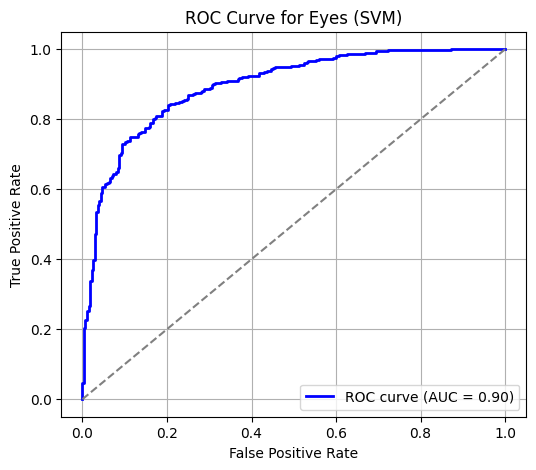

In [ ]:
#Plotting the ROC curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

#Adding labels, title, and legend
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Eyes (SVM)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()